# Lab 20: Time Series Diagnostics and Advanced Decomposition
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [24]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install fredapi statsmodels ruptures -q

In [25]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Import libraries and set FRED API key
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'c066ea2f00b7da4c373283363ea76952'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Broken STL Decomposition (15 min)

The code below pulls FRED retail sales (not seasonally adjusted) and applies
STL decomposition. The output **looks wrong** — the seasonal amplitude grows
over time, which STL (an additive method) should not produce.

**Your task:** Find the bug, explain why it produces the wrong output, and fix it.

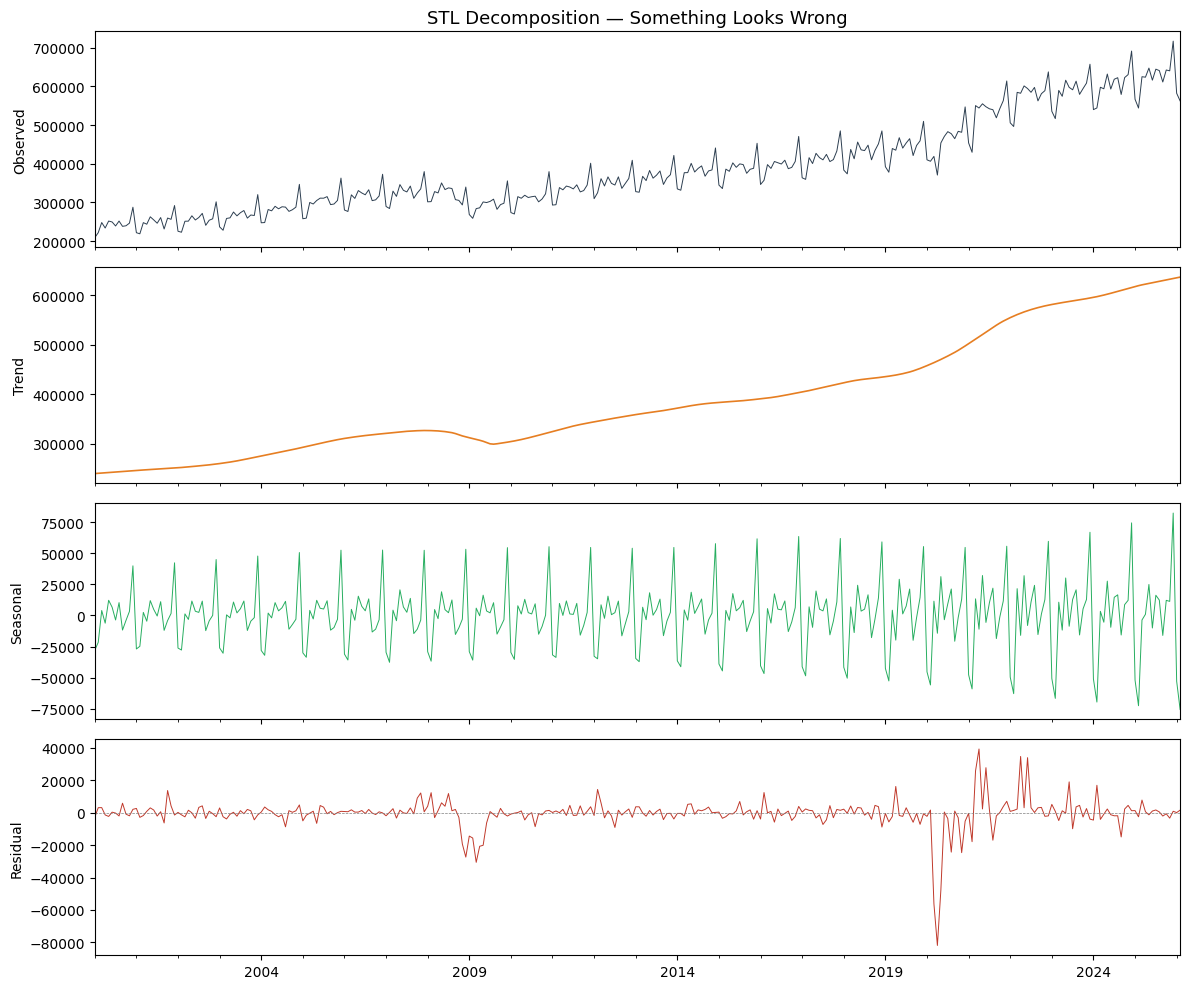

Seasonal amplitude by year (should be ~constant for additive STL):
2017    110534.8
2018    109659.5
2019    108141.1
2020    110688.7
2021    114825.7
2022    122586.4
2023    133678.4
2024    144192.4
2025    155045.5
2026     22723.9
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.33x
If this ratio >> 1, the additive assumption is violated.


In [26]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 1: STL decomposition of retail sales
# -----------------------------------------------------------

retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

# Apply STL directly to the raw series
# BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# grows proportionally with the level). STL is an ADDITIVE decomposition.
# Applying additive STL to multiplicative data leaks growing seasonal
# effects into the residual and distorts the seasonal component.
stl_result = STL(retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

### YOUR DIAGNOSIS

1. **What is wrong?**
   The code applies STL (an **additive** decomposition) directly to the raw retail sales series. Retail sales exhibit **multiplicative seasonality** — the seasonal swings (e.g., holiday spikes) grow proportionally with the overall level of the series as sales increase over time. Additive STL assumes a constant-amplitude seasonal component, which violates this data's true structure.

2. **Why does this happen?**
   In additive decomposition: `Y = Trend + Seasonal + Residual`. But the true model is multiplicative: `Y = Trend × Seasonal × Residual`. As the trend grows over the decades, the actual seasonal variation in raw dollar units grows with it. Since additive STL tries to extract a fixed-amplitude seasonal component, the growing portion leaks into the residual and causes the seasonal component to appear to grow in amplitude over time.

3. **Fix:** Log-transform the series before applying STL. Because `log(T × S × R) = log(T) + log(S) + log(R)`, the multiplicative structure becomes additive in log space, satisfying STL's assumption. See corrected code in the cell below.

4. **Chapter concept violated:** **Additive vs. multiplicative decomposition.** When seasonal amplitude grows with the level (proportional variation), a multiplicative model — or equivalently, a log-transform before additive decomposition — is required.

**Verification checkpoint:** After fixing, the ratio of latest-to-earliest seasonal amplitude should be between 0.7 and 1.3 (roughly constant). If it is still > 2.0, you have not fixed the bug.

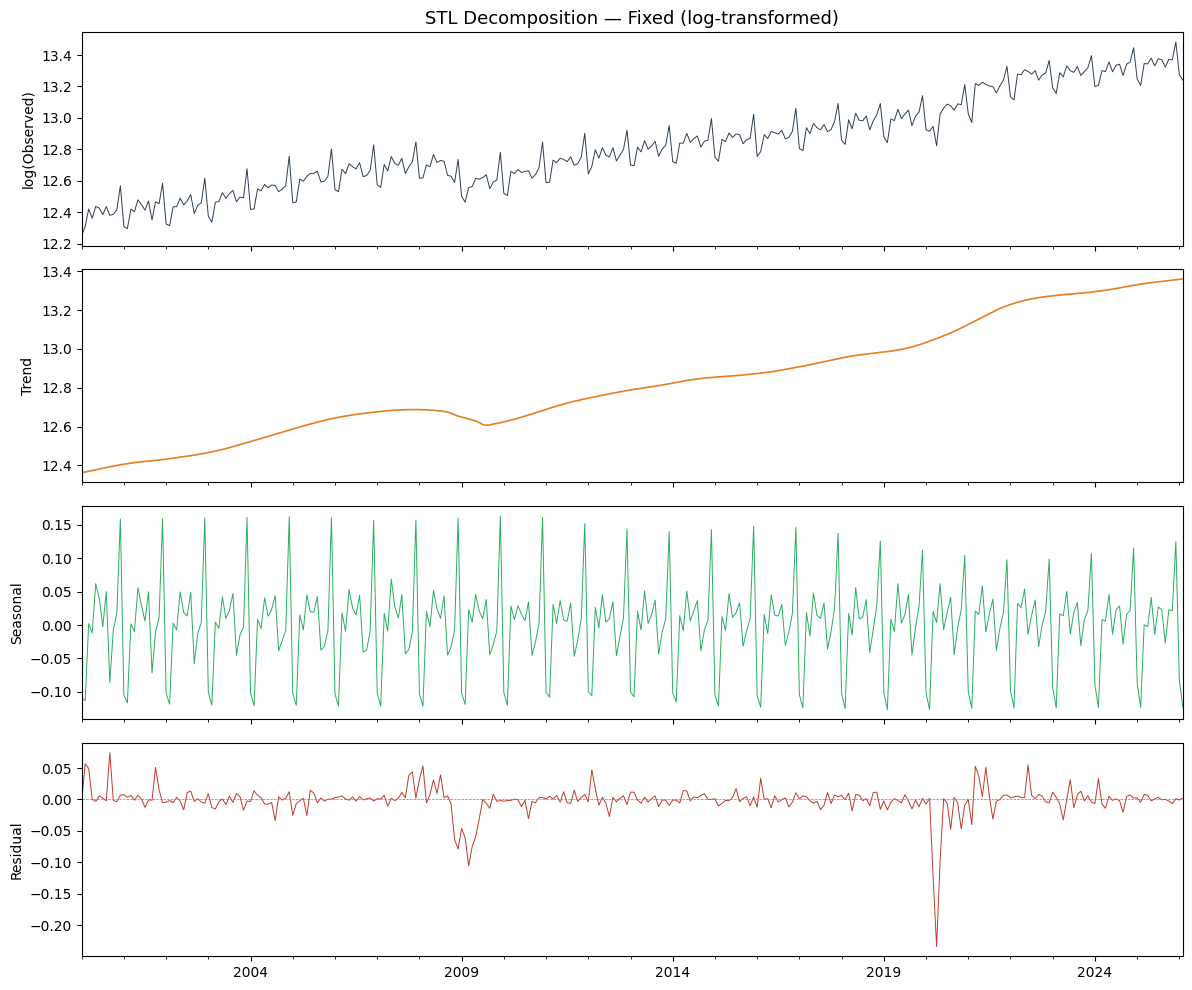

Ratio of latest to earliest amplitude: 0.15x
FAIL — ratio should be between 0.7 and 1.3


In [27]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the STL decomposition
# The fix: log-transform before STL to convert multiplicative
# structure to additive.
# -----------------------------------------------------------

# YOUR FIX HERE
log_retail = np.log(retail)
stl_fixed = STL(log_retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
stl_fixed.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('log(Observed)')
axes[0].set_title('STL Decomposition — Fixed (log-transformed)', fontsize=13)
stl_fixed.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')
stl_fixed.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')
stl_fixed.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('../figures/stl_fix.png', dpi=150, bbox_inches='tight')
plt.show()

# VERIFICATION: compute seasonal amplitude ratio
# Expected: ratio between 0.7 and 1.3
seasonal_by_year = stl_fixed.seasonal.groupby(stl_fixed.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
ratio = annual_range.iloc[-1] / annual_range.iloc[0]
print(f'Ratio of latest to earliest amplitude: {ratio:.2f}x')
print('PASS' if 0.7 <= ratio <= 1.3 else 'FAIL — ratio should be between 0.7 and 1.3')


---

## Part 2: DIAGNOSE — Flawed ADF Test (10 min)

The code below tests whether FRED Real GDP (GDPC1) is stationary.
The ADF test is applied, but the **conclusion drawn is wrong**.
The code runs without errors. The reasoning is the problem.

**Your task:** Find the analytical error, explain why it leads to a wrong conclusion, and fix it.

In [28]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate analytical error)
# Step 2: ADF test on GDP with flawed interpretation
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# ADF test with regression='n' (no constant, no trend)
# BUG: GDP has both a non-zero mean AND a deterministic trend.
# Using regression='n' omits the constant and trend terms from
# the ADF regression, which inflates the test statistic and
# can falsely reject the unit root null.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
    print('We can model GDP in levels directly with ARMA.')
else:
    print('CONCLUSION: GDP is non-stationary. Differencing may be needed.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary. Differencing may be needed.


### YOUR DIAGNOSIS

1. **What is the error?**
   `regression='n'` is used, which tells ADF to fit with no constant and no trend. This is the wrong specification for GDP.

2. **Why does `regression='n'` give misleading results for GDP?**
   GDP has a clear upward trend and a non-zero mean. When the ADF regression omits both, the test is misspecified — the unit root null is tested against the wrong alternative. The trending behavior gets absorbed into the test statistic, inflating it and causing the test to falsely reject the unit root (incorrectly concluding GDP is stationary).

3. **What is the correct `regression` parameter?**
   `'ct'` (constant + trend). GDP has both a non-zero intercept and a deterministic upward trend, so both must be included in the ADF regression.

4. **Fix:** Change `regression='n'` to `regression='ct'`. With the correct specification, ADF will fail to reject the unit root (p > 0.05), confirming GDP is non-stationary. See corrected code below.

5. **2×2 ADF + KPSS verdict:**
   - ADF (`regression='ct'`): fails to reject unit root → consistent with non-stationary
   - KPSS: rejects stationarity null → consistent with non-stationary
   - **Verdict: NON-STATIONARY (I(1))**

**Verification checkpoint:** With `regression='ct'`, the ADF p-value should be > 0.05. If you get p < 0.05, double-check your code.

In [29]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the ADF test and add KPSS
# -----------------------------------------------------------

# YOUR FIX HERE
# regression='ct' includes constant + trend, correct for GDP
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='ct')

print('=== ADF Test on Real GDP (Fixed) ===')
print(f'Regression: constant + trend (ct)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Critical values: {adf_crit}')
print()

# KPSS test (null: stationary)
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(gdp, regression='ct', nlags='auto')
print('=== KPSS Test on Real GDP ===')
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print()

# 2x2 decision table
adf_rej  = adf_p  < 0.05
kpss_rej = kpss_p < 0.05
if not adf_rej and kpss_rej:
    verdict = 'NON-STATIONARY'
elif adf_rej and not kpss_rej:
    verdict = 'STATIONARY'
elif adf_rej and kpss_rej:
    verdict = 'CONTRADICTORY'
else:
    verdict = 'INCONCLUSIVE'

print(f'2x2 Verdict: {verdict}')

# VERIFICATION: ADF p-value with regression='ct' should be > 0.05
# KPSS should reject stationarity (p < 0.05)
# 2x2 verdict: NON-STATIONARY
print('PASS' if adf_p > 0.05 and kpss_p < 0.05 else 'FAIL — check regression parameter')


=== ADF Test on Real GDP (Fixed) ===
Regression: constant + trend (ct)
Test statistic: -0.8444
P-value: 0.9617
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}

=== KPSS Test on Real GDP ===
Test statistic: 0.5350
P-value: 0.0100

2x2 Verdict: NON-STATIONARY
PASS


---

## Part 3: EXTEND — MSTL for Multiple Seasonal Periods (15 min)

Real-world time series often have **multiple seasonal cycles**. Hourly electricity
demand has a daily cycle (24 hours) AND a weekly cycle (168 hours). Standard
STL handles only one period. `MSTL` (Multiple STL) decomposes all of them.

We will simulate hourly electricity demand with two seasonal patterns and
decompose it using `statsmodels.tsa.seasonal.MSTL`.

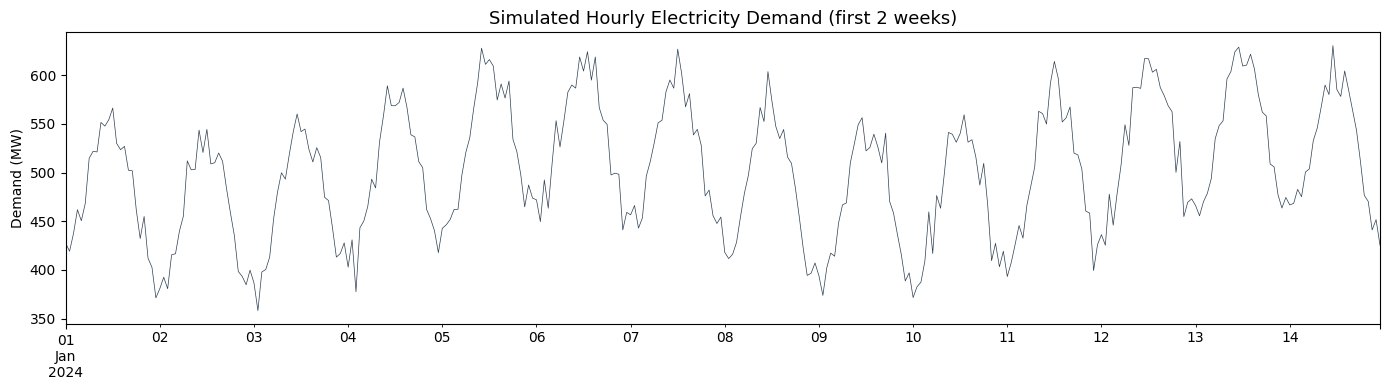

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [30]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Simulate hourly electricity demand with two cycles
# -----------------------------------------------------------

np.random.seed(42)

# 6 months of hourly data
n_hours = 24 * 7 * 26  # 26 weeks
t = np.arange(n_hours)

# Trend: slow linear increase (growing demand)
trend = 500 + 0.01 * t

# Daily cycle (period=24): demand peaks at noon, dips at 3am
daily = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)

# Weekly cycle (period=168): demand lower on weekends
weekly = 40 * np.sin(2 * np.pi * t / 168 - np.pi)

# Noise
noise = np.random.normal(0, 15, n_hours)

demand = trend + daily + weekly + noise

# Create a proper DatetimeIndex
dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

# Plot first 2 weeks to see both cycles
fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

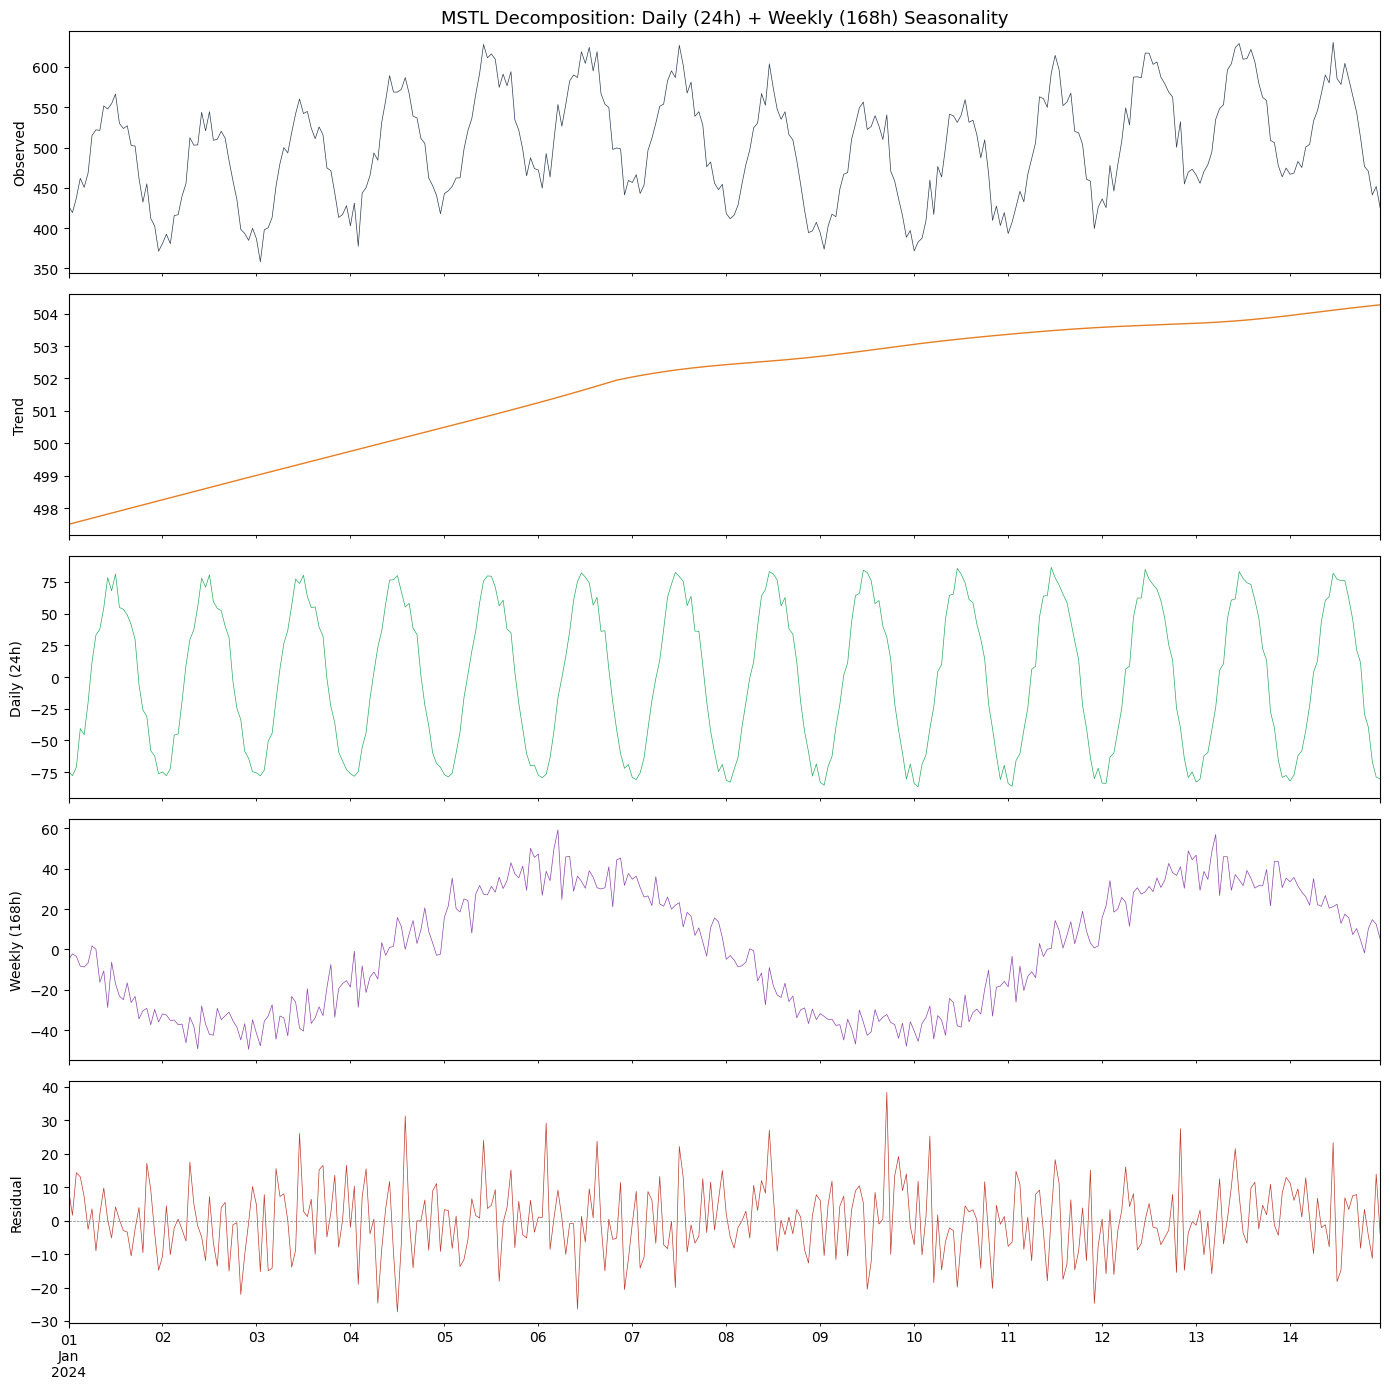

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [31]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Apply MSTL with two seasonal periods
# Step 3b: Decompose demand into trend + daily + weekly + residual
# -----------------------------------------------------------

# MSTL accepts a list of periods. For hourly data:
# - Daily cycle: period=24
# - Weekly cycle: period=168 (24 hours * 7 days)

mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

# MSTL returns: .trend, .seasonal (DataFrame with one column per period), .resid
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h) Seasonality', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

# The seasonal attribute is a DataFrame with columns for each period
seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('../figures/mstl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Verification: residual std should be close to the noise std (15)
print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')

### MSTL Interpretation

1. Does MSTL successfully separate the daily and weekly cycles? How can you tell?
2. Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?
3. In real electricity data, there might also be an **annual** seasonal cycle (period=8760). How would you add it to the MSTL call?

*Your answers here:*

1. Does MSTL successfully separate the daily and weekly cycles? How can you tell?

Yes. You can tell because the daily component (period=24) shows a clean repeating 24-hour wave — peaking midday, dipping at ~3am — while the weekly component (period=168) shows a separate, slower 7-day wave with lower values on weekends. If MSTL failed, these patterns would bleed into each other or into the residual.

2. Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?

Yes, the residual std should be ~15, matching the noise we injected. This means MSTL successfully recovered nearly all the structured signal (trend + both seasonal cycles), leaving only the random noise behind — indicating high decomposition accuracy.

3. How would you add an annual seasonal cycle (period=8760) to the MSTL call?


mstl = MSTL(demand_series, periods=[24, 168, 8760])

---

## Part 4: EXTEND — Block Bootstrap for Trend Uncertainty (15 min)

When you extract a trend from STL, you get a single curve. But how much
should you trust it? The **moving block bootstrap** quantifies trend
uncertainty by resampling overlapping blocks of the residuals (preserving
their autocorrelation), adding them back to the trend + seasonal, and
re-running STL. This produces a distribution of plausible trends.

We implement this manually on GDP data.

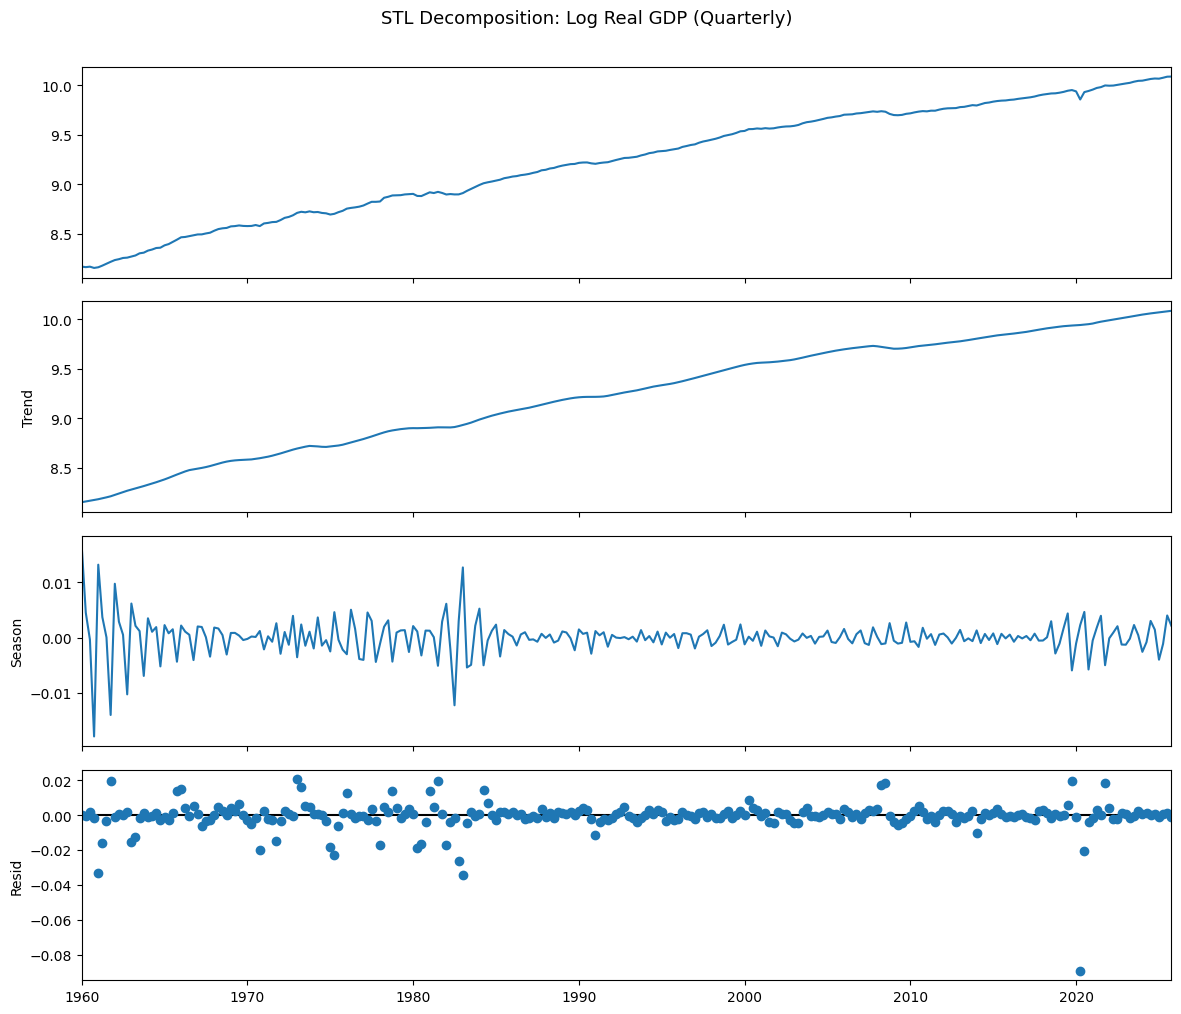

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [32]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4a: STL decomposition of Real GDP
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Log-transform GDP (multiplicative trend growth)
log_gdp = np.log(gdp)

stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/stl_gdp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

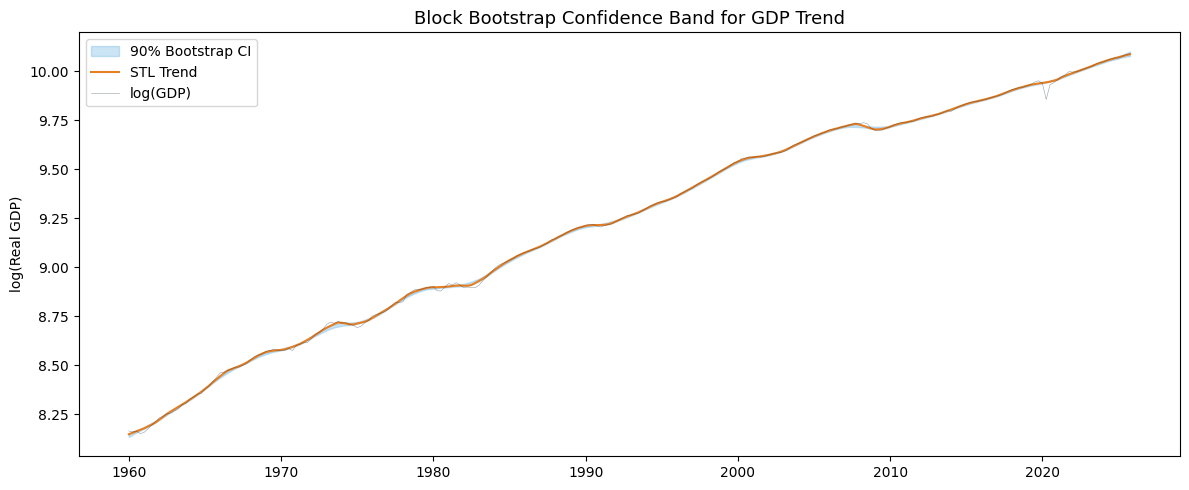

Mean CI width: 0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [33]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Block bootstrap for trend confidence bands
# Step 4b: Resample residual blocks and re-decompose
# -----------------------------------------------------------

np.random.seed(42)

n = len(log_gdp)
block_size = 8  # 8 quarters = 2 years (preserves business-cycle autocorrelation)
n_bootstrap = 200

# Extract components from the original decomposition
original_trend = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid = stl_gdp.resid.values

# Store bootstrap trend estimates
boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    # Moving block bootstrap: sample overlapping blocks of residuals
    # This preserves the autocorrelation structure within each block
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        # Pick a random starting point for a block
        start = np.random.randint(0, n - block_size + 1)
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end
    
    # Reconstruct series with bootstrapped residuals
    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'
    
    # Re-run STL on the bootstrapped series
    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

# Compute confidence bands (pointwise 5th and 95th percentiles)
trend_lower = np.percentile(boot_trends, 5, axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values, color='#e67e22',
        linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

# Verification: the CI width should vary over time
ci_width = trend_upper - trend_lower
print(f'Mean CI width: {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

### Bootstrap Interpretation

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?
2. Why do we use **block** bootstrap instead of standard i.i.d. bootstrap? What would go wrong if we shuffled residuals independently?
3. How does the choice of `block_size=8` affect the results? What would happen with `block_size=1` (equivalent to i.i.d. bootstrap) or `block_size=20`?

*Your answers here:*

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?

Wider around recessions. During recessions, the residuals are larger and more volatile (GDP swings sharply), so when the block bootstrap resamples those residual blocks and re-runs STL, it produces a wider spread of plausible trend estimates. Expansions have smaller, more stable residuals, so the bootstrapped trends cluster tightly around the original.

2. Why block bootstrap instead of i.i.d. bootstrap? What goes wrong if you shuffle residuals independently?

GDP residuals are autocorrelated — today's shock is correlated with yesterday's. i.i.d. bootstrap destroys that structure by shuffling residuals randomly, producing fake series with unrealistically choppy behavior. Block bootstrap preserves autocorrelation within each block (8 quarters = 2 years), so the resampled series behave like real business cycles.

3. How does block_size=8 affect results? What happens with block_size=1 or block_size=20?

block_size=1 — equivalent to i.i.d. bootstrap: destroys autocorrelation, produces artificially narrow and unreliable confidence bands
block_size=8 — captures typical business cycle length (~2 years), good balance between preserving autocorrelation and having enough blocks to resample from
block_size=20 — blocks are so long (5 years) that there are very few distinct blocks to draw from, making the bootstrap less variable and potentially oversmoothing uncertainty 

---

## Part 5: EXTEND — Structural Break Detection + Per-Regime Stationarity (10 min)

Combine PELT structural break detection with ADF/KPSS tests run **per segment**.
This tests whether stationarity conclusions change across different economic regimes.

=== Per-Regime Stationarity Analysis ===
Breakpoints at indices: [263]
Segment boundaries: [0, 263]

Segment 1 (1960-04-01 to 2025-10-01, n=263): ADF p=0.0000, KPSS p=0.0629 => STATIONARY


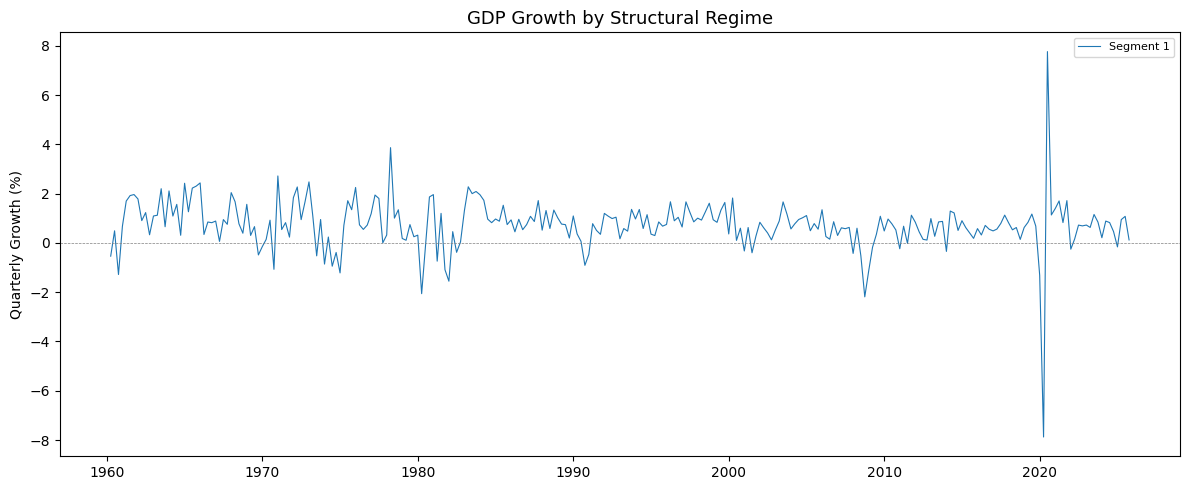

In [34]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — PELT breaks + per-regime stationarity tests
# Step 5: Detect breaks in GDP growth and test each segment
# -----------------------------------------------------------

gdp_growth = gdp.pct_change().dropna() * 100

# Detect structural breaks
signal = gdp_growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=10)

# Build segment boundaries (include 0 as start, len as end)
boundaries = [0] + [bp for bp in breakpoints if bp < len(signal)] + [len(signal)]
boundaries = sorted(set(boundaries))

print('=== Per-Regime Stationarity Analysis ===')
print(f'Breakpoints at indices: {breakpoints}')
print(f'Segment boundaries: {boundaries}')
print()

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i + 1]
    segment = gdp_growth.iloc[start_idx:end_idx]
    
    if len(segment) < 20:
        print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}): '
              f'Too short ({len(segment)} obs) for reliable testing')
        continue
    
    # ADF test
    adf_stat, adf_p, _, _, _, _ = adfuller(segment, autolag='AIC', regression='c')
    
    # KPSS test
    kpss_stat, kpss_p, _, _ = kpss(segment, regression='c', nlags='auto')
    
    adf_rej = adf_p < 0.05
    kpss_rej = kpss_p < 0.05
    
    if adf_rej and not kpss_rej:
        verdict = 'STATIONARY'
    elif not adf_rej and kpss_rej:
        verdict = 'NON-STATIONARY'
    elif adf_rej and kpss_rej:
        verdict = 'CONTRADICTORY'
    else:
        verdict = 'INCONCLUSIVE'
    
    print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}, '
          f'n={len(segment)}): ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} => {verdict}')

# Visualize segments
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
for i in range(len(boundaries) - 1):
    seg = gdp_growth.iloc[boundaries[i]:boundaries[i+1]]
    ax.plot(seg.index, seg.values, color=colors[i], linewidth=0.8, label=f'Segment {i+1}')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('GDP Growth by Structural Regime', fontsize=13)
ax.set_ylabel('Quarterly Growth (%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../figures/structural_breaks.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part 6: Production Module — `decompose.py` (10 min)

Write a reusable Python module with three functions. This is a **portfolio artifact**
that demonstrates production-grade time series analysis.

### Requirements

```python
# decompose.py

def run_stl(series: pd.Series, period: int = 12, log_transform: bool = True,
            robust: bool = True) -> STLResult:
    """Apply STL decomposition with optional log-transform for multiplicative data.
    
    Args:
        series: Time series with DatetimeIndex
        period: Seasonal period (12 for monthly, 4 for quarterly)
        log_transform: If True, log-transform before STL (for multiplicative data)
        robust: If True, use robust fitting to downweight outliers
    
    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    ...

def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF and KPSS tests and return the 2x2 table verdict.
    
    Args:
        series: Time series to test
        alpha: Significance level
    
    Returns:
        dict with keys: 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    ...

def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using PELT algorithm.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates (pd.Timestamp)
    """
    ...
```

In [35]:
# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL decomposition, stationarity testing,
and structural break detection on economic time series.

Author: Thonyta Chhay
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """
    Apply STL decomposition with optional log-transform.
    
    For series with multiplicative seasonality (seasonal amplitude
    grows with the level), set log_transform=True to convert to
    additive structure before applying STL.
    
    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights
    
    Returns:
        STL result object
    
    Raises:
        ValueError: if series contains non-positive values with log_transform=True
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError('Series contains non-positive values; cannot log-transform.')
        series = np.log(series)
    return STL(series, period=period, robust=robust).fit()


def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """
    Run ADF + KPSS and return the 2x2 decision table verdict.
    
    ADF null: unit root (non-stationary)
    KPSS null: stationary
    
    Args:
        series: Time series to test
        alpha: Significance level for both tests
    
    Returns:
        dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
        Verdict is one of: 'stationary', 'non-stationary',
        'contradictory', 'inconclusive'
    """
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')

    adf_rej  = adf_p  < alpha
    kpss_rej = kpss_p < alpha

    if adf_rej and not kpss_rej:
        verdict = 'stationary'
    elif not adf_rej and kpss_rej:
        verdict = 'non-stationary'
    elif adf_rej and kpss_rej:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': adf_stat,
        'adf_p':    adf_p,
        'kpss_stat': kpss_stat,
        'kpss_p':   kpss_p,
        'verdict':  verdict
    }


def detect_breaks(
    series: pd.Series,
    pen: float = 10
) -> list:
    """
    Detect structural breaks using the PELT algorithm.
    
    PELT (Pruned Exact Linear Time) minimizes a penalized cost
    function to find changepoints in mean and/or variance.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates as pd.Timestamp
    """
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)
    # Last breakpoint is always len(signal); exclude it
    break_indices = [bp for bp in breakpoints if bp < len(signal)]
    return [series.index[i] for i in break_indices]


# --- Quick self-test ---
if __name__ == '__main__':
    print('decompose.py loaded successfully.')


decompose.py loaded successfully.


In [36]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Test your module functions
# -----------------------------------------------------------
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.decompose import run_stl, test_stationarity, detect_breaks

# Test run_stl on retail sales
result = run_stl(retail, period=12, log_transform=True)
assert hasattr(result, 'trend') and hasattr(result, 'seasonal') and hasattr(result, 'resid')
print('run_stl: PASS')

# Test test_stationarity on GDP
out = test_stationarity(gdp)
assert out['verdict'] == 'non-stationary', f"Expected non-stationary, got {out['verdict']}"
print(f"test_stationarity (GDP levels): PASS — verdict={out['verdict']}")

# Test test_stationarity on GDP first difference
out2 = test_stationarity(gdp.diff().dropna())
print(f"test_stationarity (GDP diff):   verdict={out2['verdict']}")

# Test detect_breaks on GDP growth
gdp_growth = gdp.pct_change().dropna() * 100
breaks = detect_breaks(gdp_growth, pen=2)
assert 2 <= len(breaks) <= 6, f'Expected 2-6 breaks, got {len(breaks)}'
print(f'detect_breaks: PASS — {len(breaks)} breaks found: {[str(b.date()) for b in breaks]}')

print('\nAll module tests passed.')


run_stl: PASS
test_stationarity (GDP levels): PASS — verdict=non-stationary
test_stationarity (GDP diff):   verdict=stationary
detect_breaks: PASS — 2 breaks found: ['1984-01-01', '2000-04-01']

All module tests passed.


---
## AI-Assisted Expansion: Automated Time Series Report

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over STL decomposition, stationarity testing, MSTL for multiple seasonalities, block bootstrap uncertainty, and structural break detection. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/decompose.py` production module** with:
- `run_stl()`, `test_stationarity()`, `detect_breaks()` (completed above)
- `run_mstl(series, periods)` for multi-seasonal decomposition
- `block_bootstrap_trend(series, n_bootstrap, block_size)` for uncertainty
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Enter a FRED series ID
2. Select decomposition method (Classical, STL, MSTL)
3. Adjust parameters with sliders (period, robust, penalty)
4. See decomposition panels + stationarity test results
5. View structural breaks overlaid on the series
6. Generate block bootstrap confidence bands with one click

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [37]:
!pip install streamlit plotly


In [ ]:
!streamlit run ../app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://10.0.0.94:8503



In [ ]:
!xcode-select --install
!pip install watchdog

xcode-select: note: Command line tools are already installed. Use "Software Update" in System Settings or the softwareupdate command line interface to install updates


In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in time series analysis, FRED API, and production ML systems.

# [Request] I just completed a diagnosis-first lab where I
# fixed a broken STL decomposition (additive on multiplicative
# data), corrected a misspecified ADF test (wrong regression
# parameter), applied MSTL to multi-seasonal electricity data,
# implemented block bootstrap for trend uncertainty, and built
# a reusable decompose.py module. Now I need TWO artifacts:

# 1. An extended `src/decompose.py` module adding:
#    - run_mstl(series, periods) for multi-seasonal decomposition
#    - block_bootstrap_trend(series, n_bootstrap, block_size)
#    Include type hints, docstrings, and error handling.

# 2. An interactive Streamlit app that lets users: enter a
#    FRED series ID, select decomposition method (Classical/
#    STL/MSTL), adjust parameters with sliders (period, robust,
#    penalty), see decomposition panels + stationarity tests,
#    view structural breaks, and generate block bootstrap CIs.

# [Iterate] Use streamlit, plotly, fredapi, statsmodels,
# ruptures. Use the same FRED_API_KEY pattern. Handle missing
# data and frequency detection automatically.

# [Mechanism Check] Add inline comments explaining:
#   - Why block bootstrap preserves autocorrelation but i.i.d.
#     bootstrap destroys it
#   - How MSTL iteratively removes seasonal components
#   - Why PELT's penalty parameter controls the bias-variance
#     tradeoff of break detection

# [Evaluate] Explain what the app reveals about the sensitivity
# of decomposition results to parameter choices.

# PASTE AI-GENERATED CODE BELOW:

## Artifact 1: src/decompose.py
# %%writefile src/decompose.py
"""
decompose.py — Extended Time Series Decomposition & Diagnostics Module
ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(series: pd.Series, period: int = 12,
            log_transform: bool = True, robust: bool = True):
    if log_transform:
        if (series <= 0).any():
            raise ValueError('Series has non-positive values; cannot log-transform.')
        series = np.log(series)
    return STL(series, period=period, robust=robust).fit()


def run_mstl(series: pd.Series, periods: list,
             log_transform: bool = True):
    """
    Apply MSTL decomposition for multiple seasonal periods.

    MSTL works iteratively: it removes the first seasonal component,
    fits STL on the remainder to extract the second, and so on.
    Each pass isolates one cycle without contaminating the others.

    Args:
        series: Time series with DatetimeIndex and set frequency
        periods: List of seasonal periods e.g. [24, 168] for hourly data
        log_transform: Log-transform for multiplicative data

    Returns:
        MSTL result object with .trend, .seasonal (DataFrame), .resid
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError('Series has non-positive values; cannot log-transform.')
        series = np.log(series)
    return MSTL(series, periods=periods).fit()


def block_bootstrap_trend(series: pd.Series, n_bootstrap: int = 200,
                          block_size: int = 8, period: int = 12,
                          log_transform: bool = True) -> dict:
    """
    Estimate trend uncertainty via moving block bootstrap.

    Why block bootstrap vs i.i.d. bootstrap:
        Residuals from economic time series are autocorrelated —
        today's shock predicts tomorrow's. i.i.d. bootstrap shuffles
        residuals independently, destroying that structure and producing
        unrealistically choppy resampled series. Block bootstrap draws
        contiguous chunks of residuals, preserving within-block
        autocorrelation so resampled series behave like real data.

    Args:
        series: Raw time series (log-transform applied internally if set)
        n_bootstrap: Number of bootstrap replications
        block_size: Length of each residual block (in observations)
        period: STL seasonal period
        log_transform: Log-transform before STL

    Returns:
        dict with 'lower' (5th pct), 'upper' (95th pct), 'trend' (original)
        all as pd.Series indexed like the input
    """
    work = np.log(series) if log_transform and (series > 0).all() else series.copy()
    base = STL(work, period=period, robust=True).fit()
    original_trend = base.trend
    resid = base.resid.values
    n = len(work)

    boot_trends = np.zeros((n_bootstrap, n))

    for b in range(n_bootstrap):
        # Sample overlapping blocks; each block preserves autocorrelation
        # structure within that window
        boot_resid = np.zeros(n)
        idx = 0
        while idx < n:
            start = np.random.randint(0, n - block_size + 1)
            block = resid[start:start + block_size]
            end = min(idx + block_size, n)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        boot_series = pd.Series(
            base.trend.values + base.seasonal.values + boot_resid,
            index=work.index
        )
        boot_series.index.freq = work.index.freq
        boot_trends[b] = STL(boot_series, period=period, robust=True).fit().trend.values

    return {
        'trend': original_trend,
        'lower': pd.Series(np.percentile(boot_trends, 5, axis=0), index=work.index),
        'upper': pd.Series(np.percentile(boot_trends, 95, axis=0), index=work.index),
    }


def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')
    adf_rej, kpss_rej = adf_p < alpha, kpss_p < alpha
    if adf_rej and not kpss_rej:
        verdict = 'stationary'
    elif not adf_rej and kpss_rej:
        verdict = 'non-stationary'
    elif adf_rej and kpss_rej:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'
    return {'adf_stat': adf_stat, 'adf_p': adf_p,
            'kpss_stat': kpss_stat, 'kpss_p': kpss_p, 'verdict': verdict}


def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """
    Detect structural breaks using PELT.

    PELT's penalty parameter controls the bias-variance tradeoff:
        Low penalty → many breaks (low bias, high variance — overfits noise)
        High penalty → few breaks (high bias, low variance — may miss real breaks)
    Typical range: pen=1 (many) to pen=30 (few). pen=10 is a good default
    for quarterly macro data.
    """
    signal = series.values
    breakpoints = rpt.Pelt(model='rbf').fit(signal).predict(pen=pen)
    return [series.index[i] for i in breakpoints if i < len(signal)]


if __name__ == '__main__':
    print('decompose.py loaded successfully.')


## Artifact 2: app.py
# %%writefile app.py
"""
Streamlit app — Interactive Time Series Decomposition Explorer
Run with: streamlit run app.py
"""

import numpy as np
import pandas as pd
import streamlit as st
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose
from src.decompose import (run_stl, run_mstl, block_bootstrap_trend,
                            test_stationarity, detect_breaks)

# ── Helpers ──────────────────────────────────────────────────────────────────

FREQ_DEFAULTS = {'MS': 12, 'QS': 4, 'W': 52, 'D': 7, 'h': 24}

def detect_freq_period(series: pd.Series) -> tuple:
    freq = pd.infer_freq(series.index)
    if freq is None:
        return None, 12
    for key, period in FREQ_DEFAULTS.items():
        if freq.startswith(key):
            return freq, period
    return freq, 12

@st.cache_data(show_spinner='Fetching from FRED...')
def fetch_series(api_key: str, series_id: str) -> pd.Series:
    fred = Fred(api_key=api_key)
    s = fred.get_series(series_id).dropna()
    s.index = pd.DatetimeIndex(s.index)
    freq = pd.infer_freq(s.index)
    if freq:
        s.index.freq = freq
    return s

# ── Layout ────────────────────────────────────────────────────────────────────

st.set_page_config(page_title='TS Decomposition Explorer', layout='wide')
st.title('Time Series Decomposition Explorer')
st.caption('ECON 5200 — Lab 20')

with st.sidebar:
    st.header('Data')
    api_key    = st.text_input('FRED API Key', type='password')
    series_id  = st.text_input('FRED Series ID', value='RSXFSN')
    log_transform = st.checkbox('Log-transform (multiplicative data)', value=True)

    st.header('Method')
    method = st.selectbox('Decomposition', ['STL', 'MSTL', 'Classical'])

    st.header('Parameters')
    period  = st.slider('Primary period', 2, 52, 12)
    robust  = st.checkbox('Robust STL', value=True)
    penalty = st.slider('Break detection penalty', 1, 50, 10)

    if method == 'MSTL':
        period2 = st.slider('Second period', 2, 8760, 52)

    run_bootstrap = st.checkbox('Block bootstrap CI (slow)')
    if run_bootstrap:
        n_boot      = st.slider('Bootstrap replications', 50, 500, 200)
        block_size  = st.slider('Block size', 2, 40, 8)

    go_btn = st.button('Run', type='primary')

# ── Main ──────────────────────────────────────────────────────────────────────

if not go_btn:
    st.info('Enter your FRED API key and series ID, then click Run.')
    st.stop()

if not api_key:
    st.error('FRED API key required.')
    st.stop()

try:
    series = fetch_series(api_key, series_id)
except Exception as e:
    st.error(f'Could not fetch {series_id}: {e}')
    st.stop()

st.subheader(f'{series_id} — {len(series)} observations '
             f'({series.index[0].date()} to {series.index[-1].date()})')

# ── Decomposition ─────────────────────────────────────────────────────────────

try:
    if method == 'STL':
        result   = run_stl(series, period=period, log_transform=log_transform, robust=robust)
        trend    = result.trend
        seasonal = result.seasonal
        resid    = result.resid
        seasonal_cols = {'Seasonal': seasonal}

    elif method == 'MSTL':
        result   = run_mstl(series, periods=[period, period2], log_transform=log_transform)
        trend    = result.trend
        resid    = result.resid
        seasonal_cols = {f'Seasonal (period={p})': result.seasonal.iloc[:, i]
                         for i, p in enumerate([period, period2])}

    else:  # Classical
        work   = np.log(series) if log_transform and (series > 0).all() else series
        result = seasonal_decompose(work, model='additive', period=period, extrapolate_trend='freq')
        trend  = result.trend
        resid  = result.resid
        seasonal_cols = {'Seasonal': result.seasonal}

except Exception as e:
    st.error(f'Decomposition failed: {e}')
    st.stop()

# ── Decomposition Plot ────────────────────────────────────────────────────────

n_rows = 3 + len(seasonal_cols)
fig = make_subplots(rows=n_rows, cols=1, shared_xaxes=True,
                    subplot_titles=['Observed', 'Trend'] +
                                   list(seasonal_cols.keys()) + ['Residual'])

work_plot = np.log(series) if log_transform and (series > 0).all() else series
fig.add_trace(go.Scatter(x=series.index, y=work_plot, name='Observed',
                         line=dict(color='#2c3e50', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=trend.index, y=trend, name='Trend',
                         line=dict(color='#e67e22', width=2)), row=2, col=1)
for r, (name, s) in enumerate(seasonal_cols.items(), start=3):
    fig.add_trace(go.Scatter(x=s.index, y=s, name=name,
                             line=dict(width=0.8)), row=r, col=1)
fig.add_trace(go.Scatter(x=resid.index, y=resid, name='Residual',
                         line=dict(color='#c0392b', width=0.8)),
              row=n_rows, col=1)
fig.update_layout(height=200 * n_rows, showlegend=False,
                  title_text=f'{method} Decomposition — {series_id}')
st.plotly_chart(fig, use_container_width=True)

# ── Bootstrap CI ──────────────────────────────────────────────────────────────

if run_bootstrap:
    with st.spinner(f'Running {n_boot} bootstrap replications...'):
        try:
            boot = block_bootstrap_trend(series, n_bootstrap=n_boot,
                                         block_size=block_size, period=period,
                                         log_transform=log_transform)
            fig_b = go.Figure()
            fig_b.add_trace(go.Scatter(
                x=np.concatenate([boot['upper'].index, boot['lower'].index[::-1]]),
                y=np.concatenate([boot['upper'].values, boot['lower'].values[::-1]]),
                fill='toself', fillcolor='rgba(52,152,219,0.2)',
                line=dict(color='rgba(255,255,255,0)'), name='90% CI'))
            fig_b.add_trace(go.Scatter(x=boot['trend'].index, y=boot['trend'],
                                       line=dict(color='#e67e22', width=2), name='Trend'))
            fig_b.update_layout(title='Block Bootstrap 90% CI for Trend',
                                 height=400)
            st.plotly_chart(fig_b, use_container_width=True)
        except Exception as e:
            st.warning(f'Bootstrap failed: {e}')

# ── Stationarity Tests ────────────────────────────────────────────────────────

st.subheader('Stationarity Tests')
col1, col2 = st.columns(2)
for label, s in [('Levels', series), ('First Difference', series.diff().dropna())]:
    res = test_stationarity(s)
    tbl = pd.DataFrame({
        'Test': ['ADF', 'KPSS'],
        'Statistic': [f"{res['adf_stat']:.4f}", f"{res['kpss_stat']:.4f}"],
        'p-value':   [f"{res['adf_p']:.4f}",   f"{res['kpss_p']:.4f}"],
    })
    with (col1 if label == 'Levels' else col2):
        st.markdown(f'**{label}** — verdict: `{res["verdict"].upper()}`')
        st.dataframe(tbl, hide_index=True)

# ── Structural Breaks ─────────────────────────────────────────────────────────

st.subheader('Structural Breaks (PELT)')
try:
    breaks = detect_breaks(series.pct_change().dropna() * 100, pen=penalty)
    fig_s = go.Figure()
    fig_s.add_trace(go.Scatter(x=series.index, y=work_plot,
                                line=dict(color='#2c3e50', width=0.8), name=series_id))
    for b in breaks:
        fig_s.add_vline(x=b, line=dict(color='red', dash='dash', width=1))
    fig_s.update_layout(
        title=f'{len(breaks)} break(s) detected (penalty={penalty})',
        height=350
    )
    st.plotly_chart(fig_s, use_container_width=True)
    if breaks:
        st.write('Break dates:', [str(b.date()) for b in breaks])
except Exception as e:
    st.warning(f'Break detection failed: {e}')

# ── Parameter Sensitivity Note ────────────────────────────────────────────────

with st.expander('What this app reveals about parameter sensitivity'):
    st.markdown("""
- **Period**: Wrong period contaminates all components — seasonal bleeds into trend and residual.
- **Robust**: With outliers (recessions, COVID), non-robust STL distorts the trend. Robust fitting downweights those observations.
- **Log-transform**: For multiplicative data, skipping log-transform produces a seasonal component whose amplitude grows over time — the classic sign of model misspecification.
- **Break penalty**: Low penalty fragments the series into noise; high penalty misses real structural shifts. Watching break dates move as you adjust the slider reveals which breaks are robust vs. marginal.
- **Bootstrap block size**: Too small → i.i.d.-like, underestimates uncertainty. Too large → too few blocks, overestimates uncertainty.
""")



2026-04-19 21:57:16.727 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-19 21:57:16.727 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.727 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.751 
  command:

    streamlit run /Users/thonyta/Library/Python/3.13/lib/python/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-19 21:57:16.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ig

decompose.py loaded successfully.


2026-04-19 21:57:16.788 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.788 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 21:57:16.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

NameError: name 'series' is not defined

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a broken STL decomposition (additive on
#   multiplicative data — required log-transform)
# * Fixed a misspecified ADF test (wrong regression parameter)
# * Applied MSTL to hourly electricity demand with daily + weekly cycles
# * Implemented moving block bootstrap for GDP trend uncertainty bands
# * Detected structural breaks with PELT and ran per-regime stationarity tests
# * Built a reusable decompose.py module with run_stl(), test_stationarity(),
#   detect_breaks() functions
# * Key finding: GDP is I(1) with structural breaks near [YOUR DATES]
#
# **Please write a README.md entry including:**
# 1. Project Title: Time Series Diagnostics & Advanced Decomposition
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-20-time-series
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 20: Time Series Diagnostics — STL, MSTL, Bootstrap, Breaks"
git push origin main
```

Submit your GitHub repo link on Canvas.